# الدرس السادس والعشرون : مطابقة السمات :

## الهدف :

* سنرى كيف نطابق سمات صورة مع سمات أخرى .

* سنرى كيف نستخدم " مطابق Brute-Force  و  FLANN   في OpenCV .



## أساسيات مطابق  Brute-Force :

 يعد هذا المطابق بسيطاً , حيث يأخذ موصف خاصية واحدة , في المجموعة الاولى ويطابقه مع كل السمات بالمجموعة الثانية , باستخدام بعض حسابات المسافة وأقرب واحدة يتم استعادتها .

من اجل مطابقات BF  علينا أولاً انشاء جسم BF باستخدام **()cv2.BFMatcher**. حيث يأخذ بارامترين مختلفين . الاول هو `normType`  وهذا يحدد قياسات المسافة المرغوب باستخدامها .

افتراضياً سيكون **cv2.NORM_L2  **  وهذا مناسب لل SIFT و  SURF  , وهناك أيضاً ** cv2.NORM_L1 ** .  وللموصفات السلاسلية الثنائية مثل ORB , BRIEF , BRISK الخ , هناك :
** cv2.NORM_HAMMING **.
ينبغي استخدامها , والتي تستخدم مسافة هامنغ كمقياس , وإذا كانت ORB , نستخدم 
VTA_K == 3 , 4  وعندها نستخدم  **cv2.NORM_HAMMING2 **.

 البارامتر الثاني هو متغير بولاني , crosscheck  وهو False  افتراضياً , وفيما لو كان True  , سيعيد المطابق فقط تلك النقاط بالترتيب i,j  حيث أن الموصف i بالمجموعة A يطابق الموصف j  بالمجموعة B  كالمطابق الافضل له والعكس بالعكس .
 
وبالتالي , يجب أن يتطابق الموصفان بالتبادل , حيث يعطس هذا نتائج متسقة وهو بديل جيد لاختبار المسافة المقترح بورقة D. Lowe .

وبعد انشاء ال BF  , هناك طريقتان هامتان , **()BFMatcher.match ** و **()BFMatcher.knnMatch** , الاولى ترجع أفضل مطابق , والثانية ترجع أفضل k مطابق , حيث يحدد k المستخدم , وهذا قد يفيد عندما نريد المعالجة الابعد.

ومثلما استخدمنا **()cv2.drawkeypoints** لرسم النقاط المفتاحية , فيمكن عبر **()cv2.drawMatches** أن نرسم المطابقات .

فهي تنظم صورتين أفقياً , وترسم خطوطاً بين الصورتين الاولى والثانية مظهرةً التطابقات الافضل .

وهناك أيضاً **()cv2.drawMatchesknn** , والتي ترسم أفضل k مطابق .

إذا k = 2 فسترسم خطين متطابقين لكل نقطة مفتاحية .  ولذلك علينا تمرير قناع إذا أردنا رسمه اختيارياً .

ولنرى الان مثال واحد لكل من SURF  و ORB , حيث كل منهما لديه قياسات مسافة مختلفة .


## مطابقة Brute-Force  مع موصفات  ORB :

هنا سنرى مثالاً بسيطاً حول كيفية مطابقة الخصائص بين صورتين .

وبهذه الحالة لدينا صورة تدريب وصورة استفسار . وعلينا ايجاد صورة الاستفسار في صور التدريب باستخدام مطابقة السمات 
(الصور هي  box.png , و  box_in_scene.png  )

ونستخدم موصفات SIFT  لمطابقة الخصائص , ونبدأ الان بتحميل الصور وايجاد الموصفات :


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

img1 = cv2.imread('images/query.png',0)          # queryImage
img2 = cv2.imread('images/train.jpg',0) # trainImage


In [4]:
# Initiate SIFT detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)


 ومن ثم ننشئ غرض ال BFmatcher  مع قياس مسافة **cv2.NORM_HAMMING** (بما أننا نستخدم ORB ) . ونبدل crosscheck  لنتائج أفضل , ومن ثم نستخدم طريقة **()Matcher.match**  للحصول على المطابقات الافضل بين الصورتين , ونوزعهم بشكل متصاعد بناءً على مسافاتهم , حيث المطابقات الافضل أولاً (بمسافات قصيرة ) .
 
 ومن ثم نرسم فقط أول 10 مطابقات (فقط لغرض الاظهار) ويمكنك زيادتهم كما تشاء .

In [4]:
%whos

Variable   Type       Data/Info
-------------------------------
cv2        module     <module 'cv2' from 'c:\python27\lib\cv2.pyd'>
des1       ndarray    500x32: 16000 elems, type `uint8`, 16000 bytes
des2       ndarray    500x32: 16000 elems, type `uint8`, 16000 bytes
img1       ndarray    701x500: 350500 elems, type `uint8`, 350500 bytes (342 kb)
img2       ndarray    620x730: 452600 elems, type `uint8`, 452600 bytes (441 kb)
kp1        list       n=500
kp2        list       n=500
np         module     <module 'numpy' from 'c:\<...>ages\numpy\__init__.pyc'>
orb        ORB        <ORB 02A40750>
plt        module     <module 'matplotlib.pyplo<...>s\matplotlib\pyplot.pyc'>


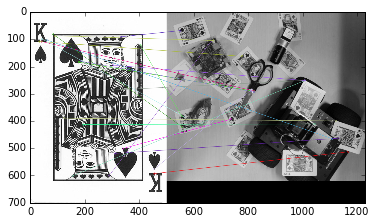

(<matplotlib.image.AxesImage at 0xd12f4f0>, None)

In [25]:
# create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors.
matches = bf.match(des1,des2)

# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)

# output_image
img3 = np.zeros([90,50])

# Draw first 10 matches.
img3 = cv2.drawMatches(img1,kp1,img2,kp2,matches[:20],img3, flags=2)

plt.figure()
plt.imshow(img3),plt.show()

### ما هو جسم المطابقة هذا :
النتيجة للامر :

` matches = bf.matches(des1,des2)`

هي قائمة لأجسام ال DMatch  , وهذه الاجسام لديها الخصائص التالية ,

* DMatch.distance :  المسافة بين المواصفات (كدلالة لشدة التطابق).

* DMatch.trainIdx :  دليل الموصفات في موصفات التدريب .

* DMatch.queryIdx :  دليل الموصفات في موصفات الاستفسار.

* DMatch.imgIdx   :  دليل صورة التدريب .



### مطابقة ال Brute-Force     مع اختيار النسبة :

وسنستخدم هذه المرة `()BFMatcher.knnMatcher `  للحصول على أفضل مطابق .

وبهذا المثال سنستخدم , k = 2 , بحيث يمكننا تطبيق اختبار المسافة المقترح من قبل D. Lowe.


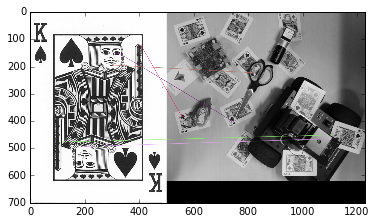

(<matplotlib.image.AxesImage at 0x785d150>, None)

In [4]:
# Initiate SIFT detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2, k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append([m])

img3 = np.zeros_like([img2,img2])

# cv2.drawMatchesKnn expects list of lists as matches.
img3 = cv2.drawMatchesKnn(img1,kp1,img2,kp2,good,img3,flags=2)

plt.imshow(img3),plt.show()

 ## مطابق FLANN :
 
 FLANN  هو اختصار للمكتبة السريعة ذات الجوار الاقرب المقرب , وتتضمن مجموعة من الخوارزميات للبحث عن الجوار الاقرب في قواعد البيانات الضخمة وللخصائص ذات الابعاد العليا . ويعمل أسرع من مطابق ال BF  للبيانات الضخمة وسنرى المثال التالي مع مطابق FLANN .
 
 ومن أجل مطابق FLANN  سنحتاج لتمرير قاموسين يحددان الخوارزمية المستخدمة وبارامتراتها المرتبطة , الخ .
 الاول هو بارامترات **IndexParams **
ومن أجل كل خوارزمية محددة نمرر البارامترات الموافقة حسب وثائق FLANN , وكنتيجة لخوارزميات مثل 
SIFT , SURF  الخ , يمكننا تمرير التالي:


In [ ]:
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

بينما يمكننا استخدام ORB  , يمكننا تمرير التالي 
(القيم في التعليقات حسب الورقة , ولكن قد لا تعمل كما ينبغي دائماً )

In [ ]:
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6, # 12
                   key_size = 12, # 20
                   multi_probe_level = 1) #2

القاموس الثاني هو بارامترات البحث , وهو يحدد عدد المرات التي يجب العكس الرجعي فيها . والقيم الاعلى تعطي دقة أعلى , ولكن على حساب الوقت .
وإذا اردت تغيير القيم , مرر , 
`search_params = dict(check = 100)`
 ومع هذه المعلومات نكتب .

In [16]:
# after taking previous Vars

# FLANN parameters
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50) # or pass empty dictionary

flann = cv2.FlannBasedMatcher(index_params,search_params)

matches = flann.knnMatch(des1,des2,k=2)

# Need to draw only good matches, so create a mask
matchesMask = [[0,0] for i in xrange(len(matches))]

# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.7*n.distance:
        matchesMask[i]=[1,0]
        
draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = (255,0,0),
                   matchesMask = matchesMask,
                   flags = 0)

img3 = np.zeros_like([img2,img2])

img3 = cv2.drawMatchesKnn(img1,kp1,img2,kp2,matches,img3,**draw_params)

plt.imshow(img3,),plt.show()

error: C:\builds\master_PackSlaveAddon-win32-vc12-static\opencv\modules\python\src2\cv2.cpp:163: error: (-215) The data should normally be NULL! in function NumpyAllocator::allocate


 لم يعمل الكود السابق , هذا نتيجة bug  في نسخة OpenCV  
كما في
[هذا الرابط](https://github.com/Itseez/opencv/issues/5667)

### مراجع اضافية 

### تمارين